# Tabular Prior-Data Fitted Network

TabPFN v2.5 es un modelo protegido ("Gated") en Hugging Face. Esto significa que no se puede descargar automáticamente sin antes aceptar su licencia de uso (que es gratuita para investigación/uso no comercial).

Se tiene que autorizarte una única vez siguiendo estos pasos:

1. Aceptar la licencia en Hugging Face.
  1. Ir a la [página oficial del modelo](https://huggingface.co/Prior-Labs/tabpfn_2_5).
  2. Iniciar sesión (o crear una cuenta).
  3. Presionar el botón o formulario para aceptar las condiciones de uso.
  4. Hacer clic en "Agree" o "Access repository".
2. Obtener tu Token de Acceso:
    1. Ir a [Configuración de Tokens](https://huggingface.co/settings/tokens).
    2. Crear un nuevo token (selecciona el tipo "Read").
    3. Copiarlo (empieza por hf_...).
3. Añadir el token al código.

## Instalación

In [25]:
#%pip install tabpfn
#%pip install scikit-learn
#%pip install pandas
#%pip install seaborn
#%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [28]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tabpfn import TabPFNRegressor

In [15]:
os.environ["HF_TOKEN"] = "HF_TOKEN_REMOVED"

In [16]:
# 1. Cargar tus datos
df = pd.read_csv('../../data/ann_and_pso_data.csv')

In [17]:
# 2. Definir Features (X) y Target (y)
# Usamos el promedio de Test1 y Test2 para tener un valor más robusto
X = df[['Nozzle temperature (C°)', 'Layer height (μm)', 'Print speed (mm/s)', 
        'Nozzle diameter (mm)', 'Infill density (%)']]
y = (df['Test1: surface roughness (µm)'] + df['Test2: surface roughness (µm)']) / 2

In [12]:
# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# 4. Inicializar TabPFN para Regresión
# TabPFN no requiere ajuste de hiperparámetros (esa es su gran ventaja)
# Cambiar a 'cuda' si se tiene GPU NVIDIA
regressor = TabPFNRegressor(device='cpu')

print("Entrenando TabPFN...")
# El .fit() es muy rápido porque no entrena pesos, solo carga el contexto
regressor.fit(X_train, y_train)

Entrenando TabPFN...


,n_estimators,8
,categorical_features_indices,None
,softmax_temperature,0.9
,average_before_softmax,False
,model_path,'auto'
,device,'cpu'
,ignore_pretraining_limits,False
,inference_precision,'auto'
,fit_mode,'fit_preprocessors'
,memory_saving_mode,'auto'
,random_state,0


In [21]:
# 5. Inferir valores
y_pred = regressor.predict(X_test)

In [22]:
# 6. Evaluar
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")

R2 Score: 0.9879
MSE: 1.2599


In [23]:
# Ejemplo de predicción con un dato nuevo
# [Temp, Layer Height, Speed, Diameter, Infill]
nuevo_dato = [[200, 150, 60, 0.4, 20]] 
prediccion = regressor.predict(nuevo_dato)
print(f"Predicción para dato nuevo: {prediccion[0]:.2f} µm")

C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but TabPFNRegressor was fitted with feature names
  warnings.warn(


Predicción para dato nuevo: 29.85 µm


El método estándar en Random Forest se llama "Disminución Media de la Impureza" (MDI).

El modelo es un árbol de decisiones que hace preguntas para separar tus datos.

1. **El objetivo:** Reducir la varianza (el error) en la predicción de la rugosidad.

2. **La pregunta:** El árbol prueba todas las variables. Por ejemplo:

  - ¿Si divido los datos por Temperatura > 200°C? (El error baja un poquito).

  - ¿Si divido los datos por Altura de Capa > 0.15mm? (El error baja muchísimo).

3. **El puntaje:** Como dividir por "Altura de Capa" redujo más el error, esa variable gana más puntos.

4. **El promedio:** Como un Random Forest tiene (por ejemplo) 100 árboles, se promedia el puntaje de cada variable en todos los árboles.

C:\Users\Erick\AppData\Local\Temp\ipykernel_45472\3102299883.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')


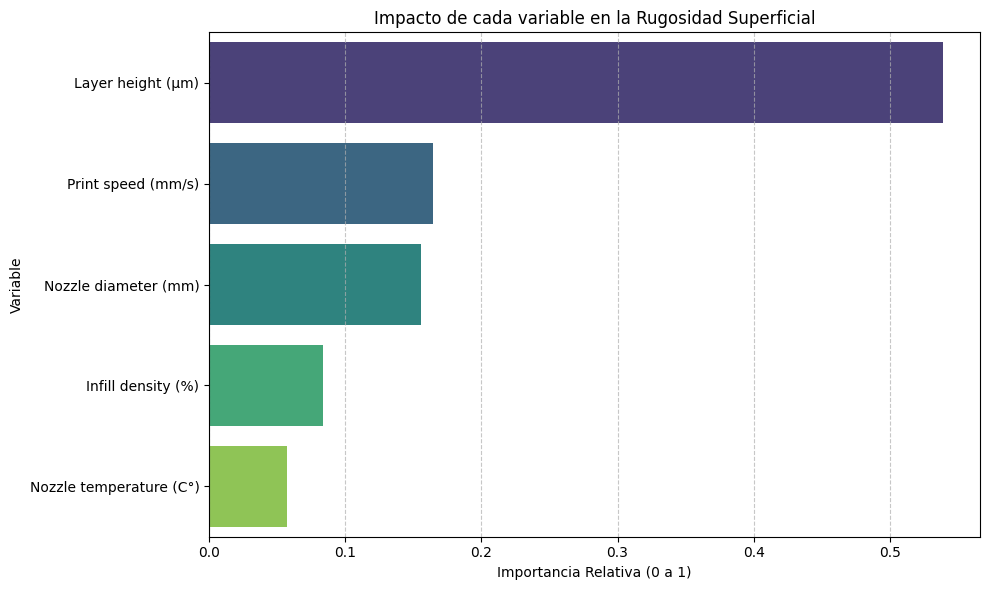

In [ ]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 8. Extraer importancia
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

# 9. Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')
plt.title('Impacto de cada variable en la Rugosidad Superficial')
plt.xlabel('Importancia Relativa (0 a 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Permutation Importance

El método anterior (MDI) tiene un defecto: a veces favorece variables con muchos valores únicos (como IDs). Además, TabPFN no tiene el atributo `.feature_importances` nativo.

Para saber qué es importante en TabPFN (o cualquier red neuronal), se usas la Importancia por Permutación

1. Entrenar el modelo.
2. Medir la precisión original ($R^2$).
3. Tomar la columna Layer height y mezclar aleatoriamente sus valores (desordenando los datos).
4. Volver a medir la precisión:
  - Si la precisión cae drásticamente, esa variable era vital
  - Si la precisión sigue igual, al modelo no le importaba esa variable.

In [29]:
# Asumiendo que 'model' es tu TabPFNRegressor o RandomForest ya entrenado
result = permutation_importance(
    rf, X_test, y_test, # Usa tu set de prueba
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# Crear DataFrame con los resultados
perm_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia Media': result.importances_mean,
    'Desviación Std': result.importances_std
}).sort_values('Importancia Media', ascending=False)

print(perm_importance)

                  Variable  Importancia Media  Desviación Std
1        Layer height (μm)           0.691360        0.294996
2       Print speed (mm/s)           0.278043        0.046706
3     Nozzle diameter (mm)           0.167382        0.076798
4       Infill density (%)           0.069234        0.036293
0  Nozzle temperature (C°)           0.042765        0.012379
